In [ ]:
olist_ecommerce_analysis.ipynb
│
├── 1. Import libraries
├── 2. Load datasets
├── 3. Inspect data and missing values
├── 4. Clean and prepare data
├── 5. Merge related tables
├── 6. KPI analysis
├── 7. Visualizations
└── 8. Business insights

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns",100)

DATA_DIR = Path(r"C:\Users\Dell\OneDrive\Desktop\My dataset.xlsx") 

In [7]:
from pathlib import Path
import pandas as pd

FILE_PATH = Path(r"C:\Users\Dell\OneDrive\Desktop\My dataset.xlsx")

# View every sheet available in the workbook
excel_file = pd.ExcelFile(FILE_PATH, engine="openpyxl")
print(excel_file.sheet_names)

['olist_customers_dataset', 'product_category_name_translati', 'olist_products_dataset', 'olist_sellers_dataset', 'olist_orders_dataset', 'olist_order_reviews_dataset', 'olist_order_payments_dataset', 'olist_order_items_dataset', 'olist_geolocation_dataset']


In [10]:
!pip install openpyxl

In [12]:
print(excel_file.sheet_names)

['olist_customers_dataset', 'product_category_name_translati', 'olist_products_dataset', 'olist_sellers_dataset', 'olist_orders_dataset', 'olist_order_reviews_dataset', 'olist_order_payments_dataset', 'olist_order_items_dataset', 'olist_geolocation_dataset']


In [16]:
df = pd.read_excel(FILE_PATH, sheet_name="olist_orders_dataset", engine="openpyxl")

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.shape)
print(df.columns.tolist())
display(df.head())

(99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [22]:
import pandas as pd
from pathlib import Path

FILE_PATH = Path(r"C:\Users\Dell\OneDrive\Desktop\My dataset.xlsx")

excel_file = pd.ExcelFile(FILE_PATH, engine="openpyxl")
print(excel_file.sheet_names)

['olist_customers_dataset', 'product_category_name_translati', 'olist_products_dataset', 'olist_sellers_dataset', 'olist_orders_dataset', 'olist_order_reviews_dataset', 'olist_order_payments_dataset', 'olist_order_items_dataset', 'olist_geolocation_dataset']


In [23]:
import pandas as pd
from pathlib import Path

FILE_PATH = Path(r"C:\Users\Dell\OneDrive\Desktop\My dataset.xlsx")

# Loads every worksheet into a dictionary
data = pd.read_excel(
    FILE_PATH,
    sheet_name=None,       # None = all sheets
    engine="openpyxl"
)

for sheet_name, sheet_df in data.items():
    print(f"{sheet_name}: {sheet_df.shape}")

olist_customers_dataset: (99441, 5)
product_category_name_translati: (72, 2)
olist_products_dataset: (32951, 9)
olist_sellers_dataset: (3095, 4)
olist_orders_dataset: (99441, 8)
olist_order_reviews_dataset: (99224, 7)
olist_order_payments_dataset: (103886, 5)
olist_order_items_dataset: (112650, 7)
olist_geolocation_dataset: (1000163, 5)


In [28]:
orders = data["olist_orders_dataset"]          # Replace "orders" with the exact sheet name
customers = data["olist_customers_dataset"]
payments = data["olist_order_payments_dataset"]

In [27]:
print(list(data.keys()))

['olist_customers_dataset', 'product_category_name_translati', 'olist_products_dataset', 'olist_sellers_dataset', 'olist_orders_dataset', 'olist_order_reviews_dataset', 'olist_order_payments_dataset', 'olist_order_items_dataset', 'olist_geolocation_dataset']


In [30]:
orders = data["olist_orders_dataset"]
items = data["olist_order_items_dataset"]
payments = data["olist_order_payments_dataset"]
customers = data["olist_customers_dataset"]
products = data["olist_products_dataset"]
sellers = data["olist_sellers_dataset"]
reviews = data["olist_order_reviews_dataset"]
geolocation = data["olist_geolocation_dataset"]
translation = data["product_category_name_translati"]

In [31]:
print(list(data.keys()))

['olist_customers_dataset', 'product_category_name_translati', 'olist_products_dataset', 'olist_sellers_dataset', 'olist_orders_dataset', 'olist_order_reviews_dataset', 'olist_order_payments_dataset', 'olist_order_items_dataset', 'olist_geolocation_dataset']


In [36]:
#Clean Dates and Validate
orders = data["olist_orders_dataset"].copy()
items = data["olist_order_items_dataset"].copy()
payments = data["olist_order_payments_dataset"].copy()
customers = data["olist_customers_dataset"].copy()
products = data["olist_products_dataset"].copy()
reviews = data["olist_order_reviews_dataset"].copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("Duplicate orders:", orders.duplicated("order_id").sum())
print("\nOrder status:")
display(orders["order_status"].value_counts())

print("\nMissing values:")
display(orders.isnull().sum().sort_values(ascending=False))


Duplicate orders: 0

Order status:


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Missing values:


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [37]:
# Aggregate item-level metrics
item_summary = (
    items.groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        product_count=("product_id", "nunique"),
        seller_count=("seller_id", "nunique"),
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

# Aggregate payment metrics
payment_summary = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_type=("payment_type", lambda x: x.mode().iloc[0]),
        installment_count=("payment_installments", "max")
    )
    .reset_index()
)

# Aggregate reviews because some orders can have multiple review rows
review_summary = (
    reviews.groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

# Create main table
df = (
    orders
    .merge(customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
           on="customer_id", how="left")
    .merge(item_summary, on="order_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(review_summary, on="order_id", how="left")
)

# Keep delivered orders for delivery and satisfaction analysis
delivered_df = df[df["order_status"] == "delivered"].copy()

# Business features
delivered_df["purchase_month"] = delivered_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
delivered_df["purchase_year"] = delivered_df["order_purchase_timestamp"].dt.year
delivered_df["purchase_weekday"] = delivered_df["order_purchase_timestamp"].dt.day_name()

delivered_df["delivery_days"] = (
    delivered_df["order_delivered_customer_date"] -
    delivered_df["order_purchase_timestamp"]
).dt.days

delivered_df["estimated_days"] = (
    delivered_df["order_estimated_delivery_date"] -
    delivered_df["order_purchase_timestamp"]
).dt.days

delivered_df["delivery_delay_days"] = (
    delivered_df["order_delivered_customer_date"] -
    delivered_df["order_estimated_delivery_date"]
).dt.days

delivered_df["is_late"] = (delivered_df["delivery_delay_days"] > 0).astype(int)

# Remove unreasonable delivery values
delivered_df = delivered_df[
    delivered_df["delivery_days"].between(0, 150)
].copy()

display(delivered_df.head())
    



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,item_count,product_count,seller_count,product_value,freight_value,payment_value,payment_type,installment_count,review_score,purchase_month,purchase_year,purchase_weekday,delivery_days,estimated_days,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,38.71,voucher,1.0,4.0,2017-10,2017,Monday,8.0,15,-8.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1.0,1.0,1.0,118.70,22.76,141.46,boleto,1.0,4.0,2018-07,2018,Tuesday,13.0,19,-6.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,179.12,credit_card,3.0,5.0,2018-08,2018,Wednesday,9.0,26,-18.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1.0,1.0,1.0,45.00,27.20,72.20,credit_card,1.0,5.0,2017-11,2017,Saturday,13.0,26,-13.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1.0,1.0,1.0,19.90,8.72,28.62,credit_card,1.0,5.0,2018-02,2018,Tuesday,2.0,12,-10.0,0


In [38]:
##Executive KPIs 

kpis = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Delivered Orders",
        "Total Revenue",
        "Average Order Value",
        "Average Delivery Days",
        "Late Delivery Rate",
        "Average Review Score"
    ],
    "Value": [
        df["order_id"].nunique(),
        delivered_df["order_id"].nunique(),
        f"R$ {delivered_df['payment_value'].sum():,.2f}",
        f"R$ {delivered_df['payment_value'].mean():,.2f}",
        f"{delivered_df['delivery_days'].mean():.1f} days",
        f"{delivered_df['is_late'].mean():.1%}",
        f"{delivered_df['review_score'].mean():.2f} / 5"
    ]
})

display(kpis)

,Metric,Value
0,Total Orders,99441
1,Delivered Orders,96446
2,Total Revenue,"R$ 15,416,068.21"
3,Average Order Value,R$ 159.84
4,Average Delivery Days,12.1 days
5,Late Delivery Rate,6.7%
6,Average Review Score,4.16 / 5


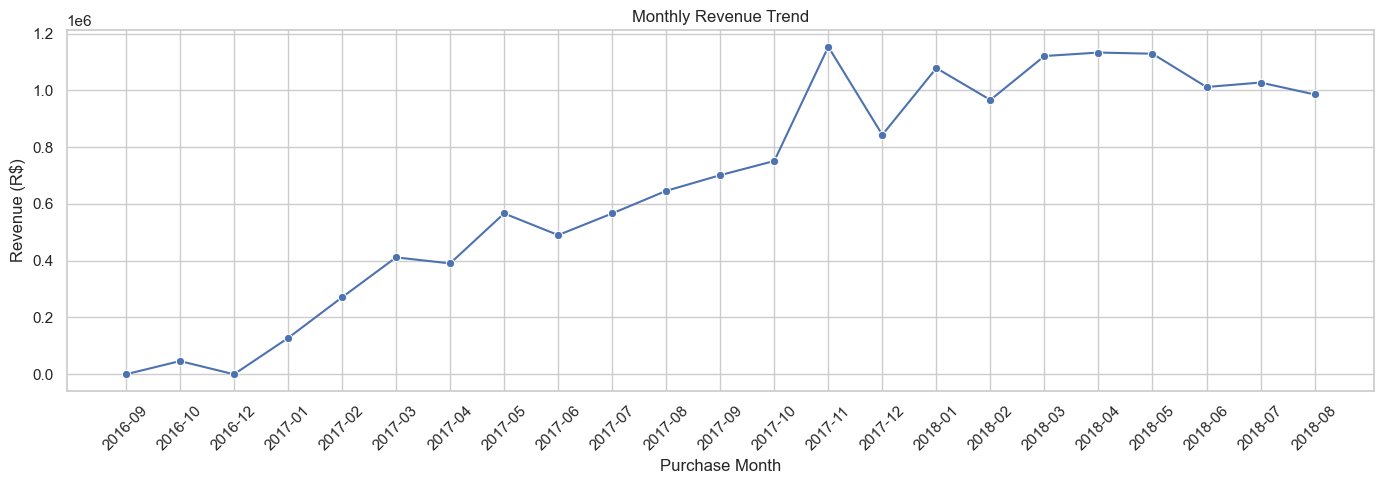

In [39]:
##Revenue Trend

monthly_revenue = (
    delivered_df.groupby("purchase_month")
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        avg_order_value=("payment_value", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x="purchase_month", y="revenue", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.show()

,customer_state,revenue,orders,avg_review_score,late_delivery_rate
0,SP,"R$ 5,768,423",40490,4.25,4.5%
1,RJ,"R$ 2,055,462",12348,3.97,12.1%
2,MG,"R$ 1,818,742",11353,4.19,4.6%
3,RS,"R$ 861,086",5342,4.19,6.0%
4,PR,"R$ 781,920",4923,4.24,4.0%
5,SC,"R$ 595,208",3546,4.13,8.2%
6,BA,"R$ 591,087",3254,3.93,12.1%
7,DF,"R$ 346,146",2080,4.13,5.7%
8,GO,"R$ 334,242",1956,4.11,6.5%
9,ES,"R$ 317,437",1994,4.08,10.7%


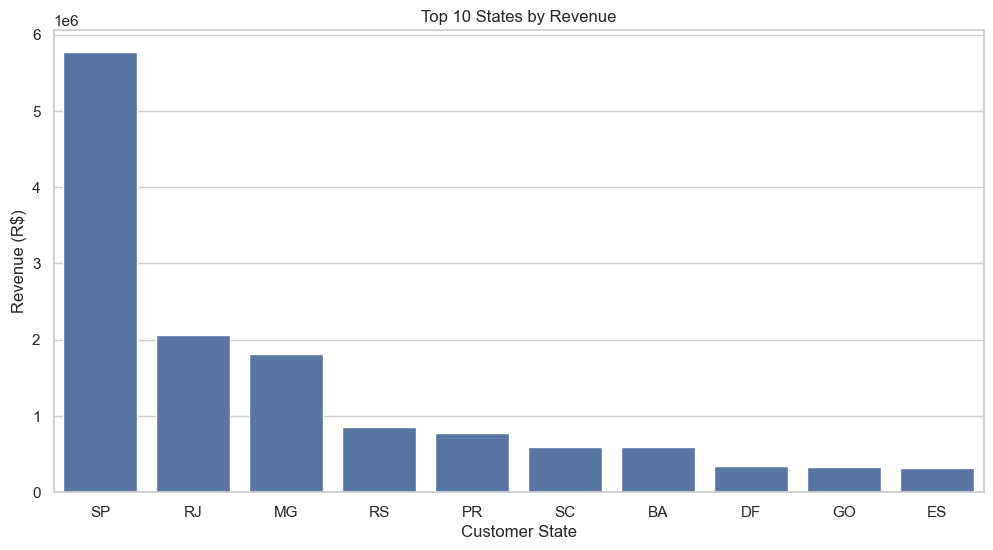

In [40]:
##Top States by Revenue 
state_performance = (
    delivered_df.groupby("customer_state")
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        late_delivery_rate=("is_late", "mean")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index()
)

display(state_performance.style.format({
    "revenue": "R$ {:,.0f}",
    "avg_review_score": "{:.2f}",
    "late_delivery_rate": "{:.1%}"
}))

plt.figure(figsize=(12, 6))
sns.barplot(data=state_performance, x="customer_state", y="revenue")
plt.title("Top 10 States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Revenue (R$)")
plt.show()

,is_late,average_review,average_delivery_days,orders,delivery_status
0,0,4.290589,10.539261,89936,On-time / Early
1,1,2.269503,32.938710,6510,Late


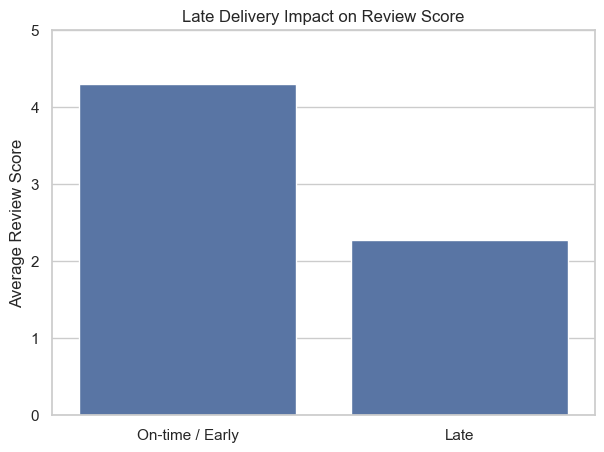

In [41]:
##Delivery performance and customer reviews
delivery_review = (
    delivered_df.groupby("is_late")
    .agg(
        average_review=("review_score", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

delivery_review["delivery_status"] = delivery_review["is_late"].map({
    0: "On-time / Early",
    1: "Late"
})

display(delivery_review)

plt.figure(figsize=(7, 5))
sns.barplot(data=delivery_review, x="delivery_status", y="average_review")
plt.ylim(0, 5)
plt.title("Late Delivery Impact on Review Score")
plt.xlabel("")
plt.ylabel("Average Review Score")
plt.show()

In [43]:
##RFM Customer segmentation

analysis_date = delivered_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    delivered_df.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (analysis_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum")
    )
    .reset_index()
)

rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1], duplicates="drop")
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4], duplicates="drop")

rfm["rfm_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

def customer_segment(row):
    if row["recency"] <= 90 and row["frequency"] >= 2:
        return "Loyal Customers"
    elif row["recency"] <= 90:
        return "Recent Customers"
    elif row["monetary"] >= rfm["monetary"].quantile(0.75):
        return "High-Value At Risk"
    return "Other Customers"

rfm["segment"] = rfm.apply(customer_segment, axis=1)

segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        average_spend=("monetary", "mean"),
        average_orders=("frequency", "mean")
    )
    .sort_values("customers", ascending=False)
)

display(segment_summary.style.format({
    "average_spend": "R$ {:,.2f}",
    "average_orders": "{:.2f}"
}))

,customers,average_spend,average_orders
segment,,,
Other Customers,56266,R$ 89.20,1.02
High-Value At Risk,18607,R$ 391.46,1.08
Recent Customers,17839,R$ 163.42,1.00
Loyal Customers,614,R$ 322.14,2.16


ROC-AUC: 0.678
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     22484
           1       0.12      0.60      0.19      1628

    accuracy                           0.66     24112
   macro avg       0.54      0.63      0.49     24112
weighted avg       0.90      0.66      0.74     24112



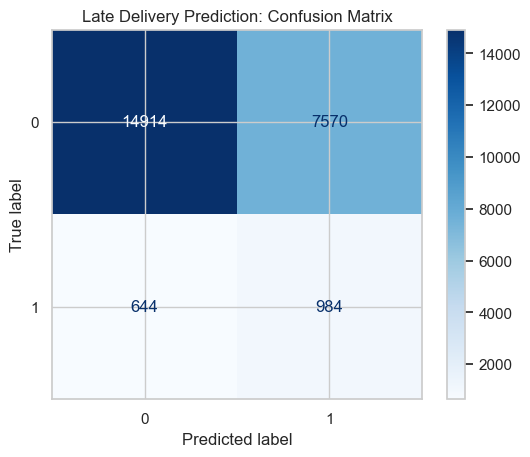

In [45]:
##Late delivery prediction model

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

numeric_features = [
    "item_count", "seller_count", "product_value", "freight_value",
    "installment_count", "purchase_hour", "purchase_dayofweek",
    "estimated_delivery_days"
]

categorical_features = ["customer_state", "payment_type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        tol=1e-3,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, probabilities), 3))
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues")
plt.title("Late Delivery Prediction: Confusion Matrix")
plt.show()

In [1]:
from pathlib import Path
print(Path.cwd())

C:\Users\Dell
